# Visualize Iris: Linear Regression, Logistic Regression, Perceptron and Train/Test

This notebook loads data/Iris.csv, performs train/test splits, fits a simple linear regression (continuous target), and fits logistic regression and perceptron for classification. It also visualizes decision boundaries and confusion matrices.

In [1]:
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, Perceptron
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix

sns.set(style="whitegrid")
DATA_PATH = Path(__file__).parent / 'data' / 'Iris.csv' if '__file__' in globals() else Path('data') / 'Iris.csv'
RANDOM_STATE = 42

def load_data(path=DATA_PATH):
    if not path.exists():
        raise FileNotFoundError(f'Iris CSV not found at: {path}')
    df = pd.read_csv(path)
    return df

In [2]:
df = load_data()
print('Dataset preview:')
df.head()

Dataset preview:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


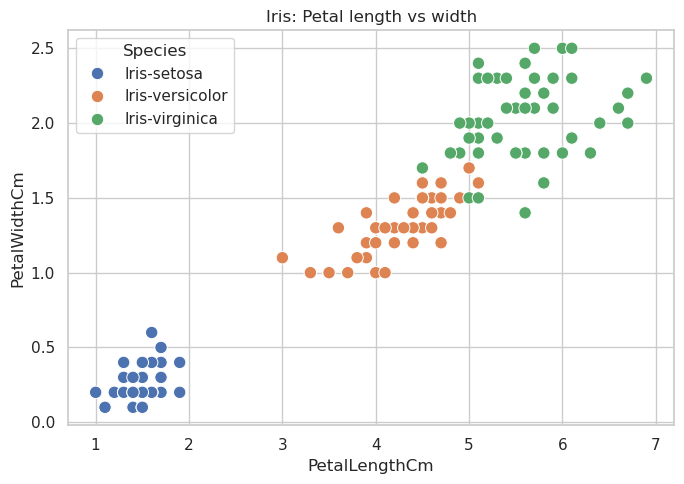

In [3]:
# Exploratory scatter: Petal length vs width
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="PetalLengthCm", y="PetalWidthCm", hue="Species", s=80)
plt.title('Iris: Petal length vs width')
plt.tight_layout()
plt.show()

## Linear regression demo
Predict PetalLengthCm from SepalLengthCm using simple linear regression.

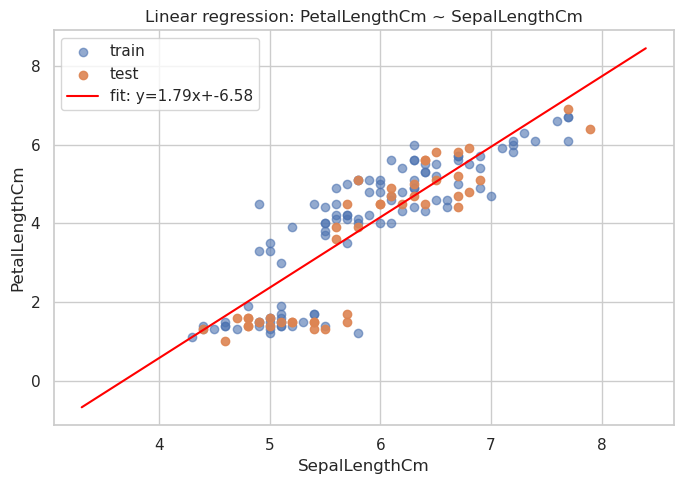

LinearRegression MSE: 0.8288


In [ ]:
# DataFrame df ထဲက input feature (SepalLengthCm) ကိုရွေးခြင်း
X = df[['SepalLengthCm']].values

# Target/output (PetalLengthCm) ကိုရွေးခြင်း
y = df['PetalLengthCm'].values

# Data ကို training (70%) နဲ့ testing (30%) ခွဲခြင်း
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Mean Squared Error (MSE) ကိုတွက်ချက်ခြင်း
mse = mean_squared_error(y_test, y_pred)

# Regression line ရဲ့ slope (coefficient) ကိုယူခြင်း
coef = model.coef_[0]
intercept = model.intercept_

plt.figure(figsize=(7,5))
plt.scatter(X_train, y_train, label='train', alpha=0.6)
plt.scatter(X_test, y_test, label='test', alpha=0.9)

# Regression line ဆွဲဖို့ x တန်ဖိုးများ ဖန်တီးခြင်း
xs = np.linspace(X.min() - 0.5, X.max() + 0.5, 100).reshape(-1,1)

# Linear regression line ကို plot ဆွဲခြင်း
plt.plot(xs, model.predict(xs), color='red', label=f'fit: y={coef:.2f}x+{intercept:.2f}')
plt.xlabel('SepalLengthCm')
plt.ylabel('PetalLengthCm')
plt.title('Linear regression: PetalLengthCm ~ SepalLengthCm')
plt.legend()
plt.tight_layout()
plt.show()

print(f'LinearRegression MSE: {mse:.4f}')

## Classification demo: Logistic Regression 
Use PetalLengthCm and PetalWidthCm (standardized) to classify Species. Visualize decision boundaries and confusion matrices.

In [6]:
# Prepare data and helper (shared by both models)
def plot_decision_boundary(clf, X, y, ax, title='Decision boundary', cmap='coolwarm'):
    x_min, x_max = X[:,0].min() - 1.0, X[:,0].max() + 1.0
    y_min, y_max = X[:,1].min() - 1.0, X[:,1].max() + 1.0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(grid)
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    scatter = ax.scatter(X[:,0], X[:,1], c=y, cmap=cmap, edgecolor='k', s=50)
    ax.set_title(title)
    return scatter

# features and encoding/scaling
X = df[['PetalLengthCm','PetalWidthCm']].values
y = df['Species'].values
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.3, random_state=RANDOM_STATE, stratify=y_enc)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Logistic Regression accuracy: 0.8889


/home/hmuegyi/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


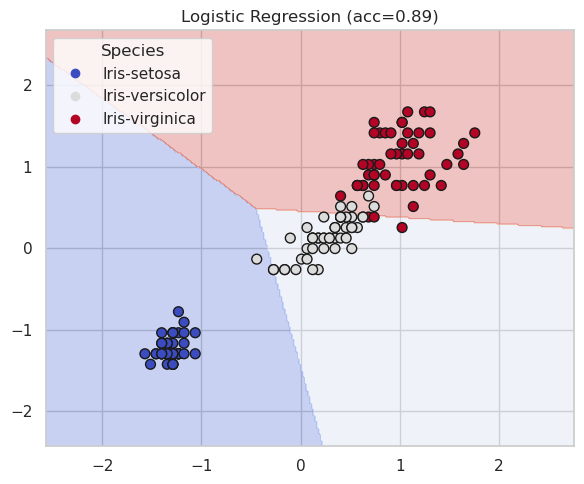

In [7]:
# Logistic Regression: train, predict, plot decision boundary and print accuracy
logreg = LogisticRegression(multi_class='ovr', solver='liblinear', random_state=RANDOM_STATE)
logreg.fit(X_train_s, y_train)
y_pred_log = logreg.predict(X_test_s)
acc_log = accuracy_score(y_test, y_pred_log)

print(f'Logistic Regression accuracy: {acc_log:.4f}')

fig, ax = plt.subplots(1,1,figsize=(6,5))
plot_decision_boundary(logreg, np.vstack([X_train_s, X_test_s]), np.hstack([y_train, y_test]), ax, title=f'Logistic Regression (acc={acc_log:.2f})')
handles, _ = ax.collections[1].legend_elements() if len(ax.collections) > 1 else (None, None)
# add legend with class names if available
if handles is not None:
    ax.legend(handles, le.classes_, title='Species')
plt.tight_layout()
plt.show()

## Classification demo: Perceptron

Perceptron accuracy: 0.9333


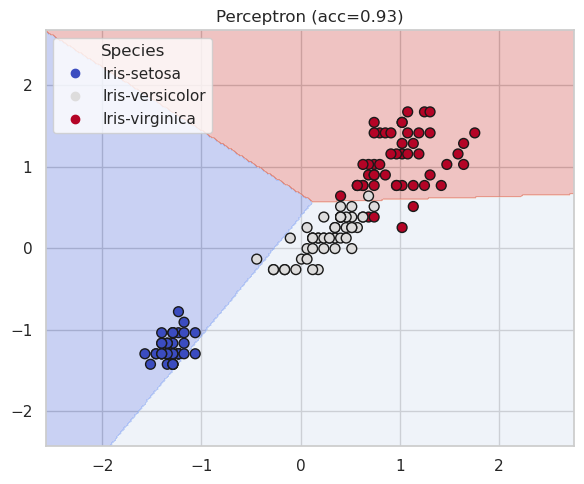

Perceptron accuracy: 0.9333


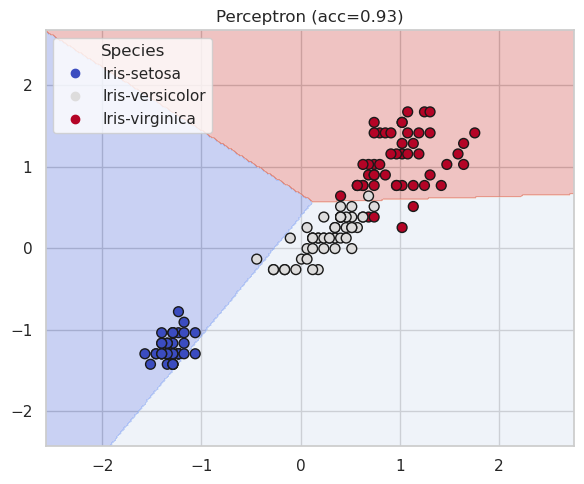

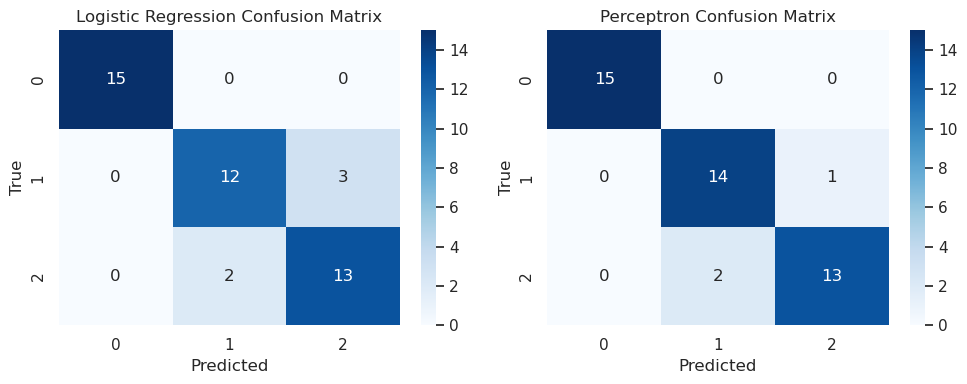

In [8]:
# Perceptron: train, predict, plot decision boundary, and show confusion matrices for both models
perc = Perceptron(random_state=RANDOM_STATE, max_iter=1000, tol=1e-3)
perc.fit(X_train_s, y_train)
y_pred_perc = perc.predict(X_test_s)
acc_perc = accuracy_score(y_test, y_pred_perc)

print(f'Perceptron accuracy: {acc_perc:.4f}')

fig, ax = plt.subplots(1,1,figsize=(6,5))
plot_decision_boundary(perc, np.vstack([X_train_s, X_test_s]), np.hstack([y_train, y_test]), ax, title=f'Perceptron (acc={acc_perc:.2f})')
handles, _ = ax.collections[1].legend_elements() if len(ax.collections) > 1 else (None, None)
if handles is not None:
    ax.legend(handles, le.classes_, title='Species')
plt.tight_layout()
plt.show()

# Confusion matrices: use y_test vs predictions from both models
cm_log = confusion_matrix(y_test, y_pred_log)
cm_perc = confusion_matrix(y_test, y_pred_perc)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm_log, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
sns.heatmap(cm_perc, annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('Perceptron Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.tight_layout()
plt.show()

### Notes
- If the notebook can't find data/Iris.csv adjust the path at the top.
- Install dependencies: numpy, pandas, matplotlib, seaborn, scikit-learn.